# 02 Feature Engineering

The raw schema is transaction wide but model thin. Three of the four downstream notebooks (segmentation, forecasting, rating) need temporal, customer, and basket features that do not exist in the source CSV. This notebook builds them once, persists the result to `data/processed/transactions.parquet`, and lets every later notebook read a single tidy artifact.

The features fall into four groups:

| Group | New columns | Why we need them |
|-------|-------------|------------------|
| Temporal | `DateTime`, `Hour`, `DayOfWeek`, `DayOfWeekIdx`, `Month`, `MonthIdx`, `IsWeekend` | Forecasting needs a daily index. Rating prediction needs hour and weekend signals. The dashboard needs month labels for the trend chart. |
| Customer | `IsMember`, `IsFemale` | Boolean encodings for downstream linear and tree models, easier to read than one hot dummies for a binary. |
| Basket | `UnitMargin`, `BasketTier` | Per item value (revenue per quantity) and a coarse high to low ticket bucket used by the segment recommendations. |
| Identity | (already present) `Branch`, `City`, `Product line`, `Payment` | Carried through unchanged so the engineered table is a superset of the cleaned table. |

The cleaned input has zero NaN (verified at the end of notebook 01), so feature engineering is purely additive. No row is dropped here.

In [1]:
import os, warnings
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')
os.environ.setdefault('TQDM_DISABLE', '1')
warnings.filterwarnings('ignore')
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.viz import set_style, fmt_money

set_style()
RNG = np.random.default_rng(config.RANDOM_SEED)


In [2]:
from src.features import engineer

clean = pd.read_parquet(config.DATA_PROCESSED / 'transactions_clean.parquet')
assert clean.isna().sum().sum() == 0, 'transactions_clean.parquet has NaN, re-run notebook 00'
df = engineer(clean)
print('input shape:', clean.shape, '-> engineered shape:', df.shape)
df.head()


input shape: (960, 17) -> engineered shape: (960, 28)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,Hour,DayOfWeek,DayOfWeekIdx,Month,MonthIdx,IsWeekend,IsMember,IsFemale,UnitMargin,BasketTier
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,...,13,Saturday,5,January,1,1,1,1,78.4245,VeryHigh
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,...,10,Friday,4,March,3,0,0,1,16.0440,Low
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,...,13,Sunday,6,March,3,1,0,0,48.6465,High
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,...,20,Sunday,6,January,1,1,1,0,61.1310,High
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,...,10,Friday,4,February,2,0,0,0,90.6255,VeryHigh


## Sanity checks on derived columns

The describe output is split into two tables, numeric and categorical, on purpose. `pandas.describe(include='all')` mixes both kinds in a single table and pads the cells where a statistic does not apply (for example mean of a string column, or unique of a numeric column) with NaN. Those NaNs are display artifacts, not data issues. Splitting by dtype keeps the output clean and obvious.

The describe table below is a sanity check, not analysis. Each derived column should fall in the range its definition implies: `Hour` between 10 and 20 (mall opening hours), `IsWeekend` and member or gender flags between 0 and 1, and `BasketTier` taking one of four ordinal labels.

In [3]:
num_cols = ['Hour', 'IsWeekend', 'IsMember', 'IsFemale']
cat_cols = ['DayOfWeek', 'Month', 'BasketTier']

print('Numeric features')
display(df[num_cols].describe().T.round(3))

print()
print('Categorical features')
display(df[cat_cols].describe().T)


Numeric features


,count,mean,std,min,25%,50%,75%,max
Hour,960.0,14.934,3.182,10.0,12.0,15.0,18.0,20.0
IsWeekend,960.0,0.298,0.458,0.0,0.0,0.0,1.0,1.0
IsMember,960.0,0.450,0.498,0.0,0.0,0.0,1.0,1.0
IsFemale,960.0,0.502,0.500,0.0,0.0,1.0,1.0,1.0



Categorical features


,count,unique,top,freq
DayOfWeek,960,7,Saturday,157
Month,960,3,March,336
BasketTier,960,4,Mid,343


## Hour of day pattern


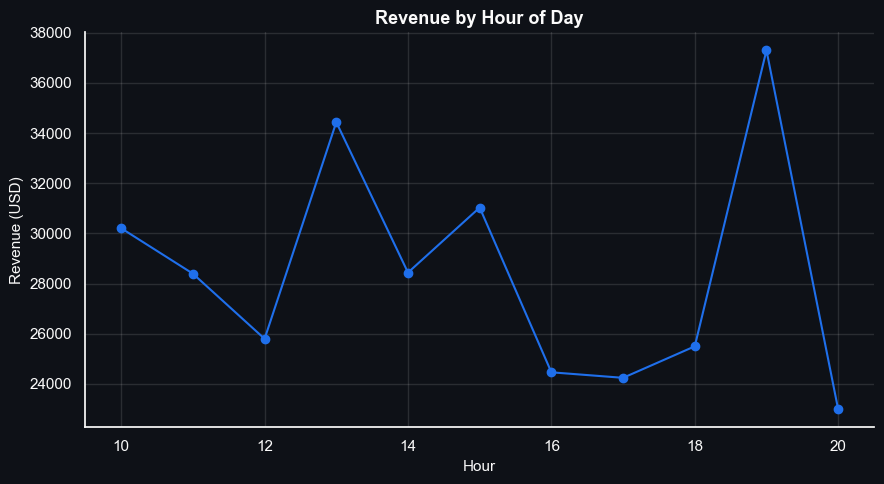

In [4]:
hourly = df.groupby('Hour')['Total'].sum()
ax = hourly.plot(marker='o', color='#1f6feb')
ax.set_title('Revenue by Hour of Day')
ax.set_ylabel('Revenue (USD)')
plt.tight_layout(); plt.show()


## Weekend vs weekday


In [5]:
wk = df.groupby('IsWeekend').agg(Revenue=('Total', 'sum'), Transactions=('Invoice ID', 'count'), AvgTicket=('Total', 'mean'))
wk.index = ['Weekday', 'Weekend']
wk


,Revenue,Transactions,AvgTicket
Weekday,216280.1708,674,320.890461
Weekend,96494.5118,286,337.393398


## Persist the engineered table


The output parquet has 28 columns: the original 17 from `transactions_clean.parquet` plus 11 engineered features. Notebooks 03 to 06 and the Streamlit app read this single file. If the schema needs to change, this is the only notebook to touch.

In [6]:
config.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_parquet(config.TRANSACTIONS_PARQUET, index=False)
print('written:', config.TRANSACTIONS_PARQUET, 'rows:', len(df))


written: D:\ZE5 PORTOFOLIO DS\Retail-Analytics-And-Forecasting-Platform\data\processed\transactions.parquet rows: 960
